# API Data Wrangling with Open-Meteo

In this exercise, we will:

- Fetch historical weather data using the **Open-Meteo API**.
- Parse and clean the data using **pandas**.
- Perform exploratory data analysis.
- Visualize weather trends.

In [1]:
# Install required packages if not already installed
# !pip install requests pandas matplotlib --quiet

In [2]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

## Understand the Open-Meteo API

- **API Endpoint**: `https://archive-api.open-meteo.com/v1/archive`
- **Parameters**:
  - `latitude`: Latitude of the location.
  - `longitude`: Longitude of the location.
  - `start_date`: Start date of the data (YYYY-MM-DD).
  - `end_date`: End date of the data (YYYY-MM-DD).
  - `hourly`: Comma-separated list of variables (e.g., temperature, precipitation).
  - `timezone`: Timezone of the data.

**Documentation**: [Open-Meteo API Docs](https://open-meteo.com/en/docs)

In [3]:
# Step 1: Set Up Parameters

# Location coordinates for New York City
latitude = 40.7128
longitude = -74.0060

# Date range
start_date = '2023-01-01'
end_date = '2023-01-07'  # One week of data

# Variables to fetch
hourly_variables = ['temperature_2m', 'relativehumidity_2m', 'precipitation']


In [4]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/New_York'
}

response = requests.get(base_url, params=params)


In [5]:
# Check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {response.status_code}')


Data fetched successfully!


In [6]:
# Step 3: Load Data into pandas DataFrame

data = response.json()
hourly_data = data['hourly']

df = pd.DataFrame(hourly_data)
df.head()


,time,temperature_2m,relativehumidity_2m,precipitation
0,2023-01-01T00:00,10.9,99,1.0
1,2023-01-01T01:00,10.6,99,1.0
2,2023-01-01T02:00,10.6,98,0.1
3,2023-01-01T03:00,10.5,96,0.0
4,2023-01-01T04:00,9.8,95,0.0


In [7]:
# Step 4: Data Cleaning

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Set 'time' as the index
df.set_index('time', inplace=True)

# Check for missing values
df.isnull().sum()


temperature_2m         0
relativehumidity_2m    0
precipitation          0
dtype: int64

In [8]:
# Handle missing values (if any)
df.ffill(inplace=True)

In [9]:
# Step 5: Exploratory Data Analysis

# Summary Statistics
df.describe()

,temperature_2m,relativehumidity_2m,precipitation
count,168.000000,168.000000,168.000000
mean,8.527976,86.422619,0.142857
std,3.496533,12.799933,0.436037
min,0.500000,45.000000,0.000000
25%,6.100000,81.000000,0.000000
50%,8.400000,90.500000,0.000000
75%,11.300000,97.000000,0.000000
max,18.000000,100.000000,3.100000


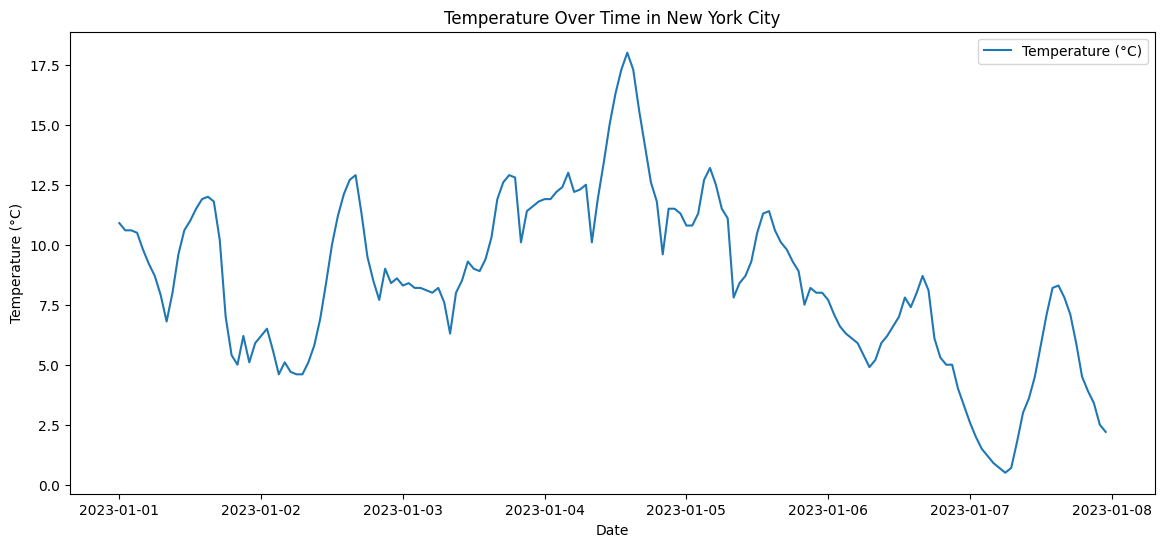

In [10]:
# Plot Temperature Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['temperature_2m'], label='Temperature (°C)')
plt.title('Temperature Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

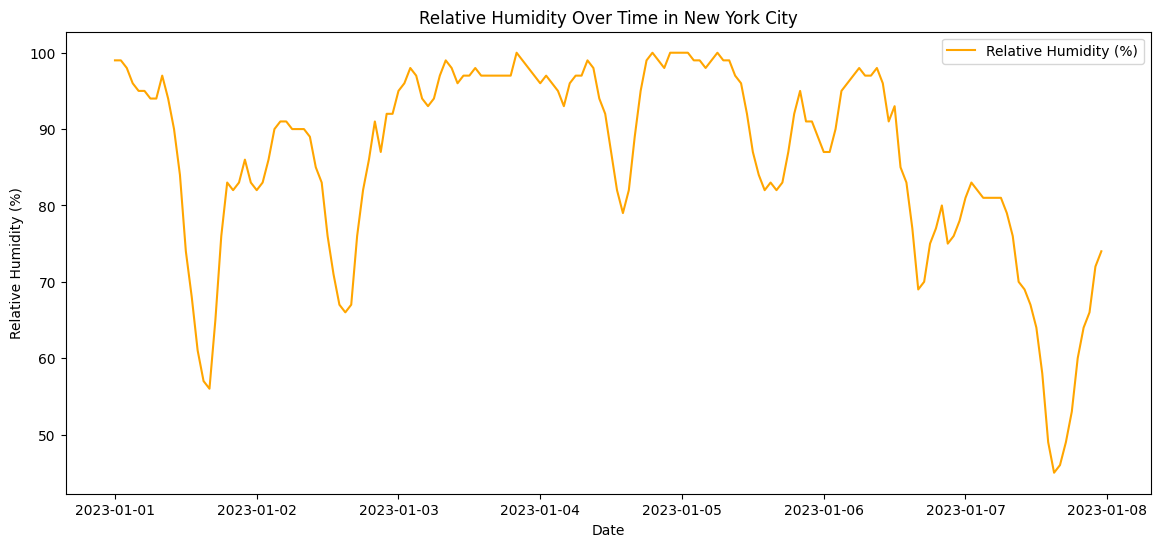

In [11]:
# Plot Relative Humidity Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['relativehumidity_2m'], color='orange', label='Relative Humidity (%)')
plt.title('Relative Humidity Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()


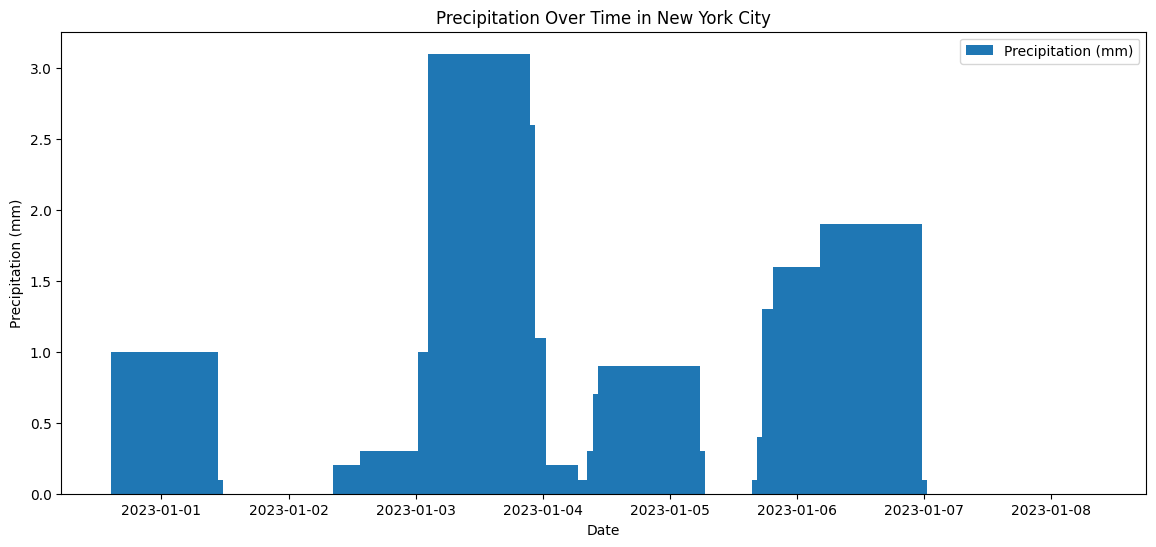

In [12]:
# Plot Precipitation Over Time

plt.figure(figsize=(14, 6))
plt.bar(df.index, df['precipitation'], label='Precipitation (mm)')
plt.title('Precipitation Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()


In [13]:
# Step 6: Correlation Analysis

# Calculate correlation between temperature and humidity
correlation = df['temperature_2m'].corr(df['relativehumidity_2m'])
print(f'Correlation between Temperature and Relative Humidity: {correlation:.2f}')


Correlation between Temperature and Relative Humidity: 0.24


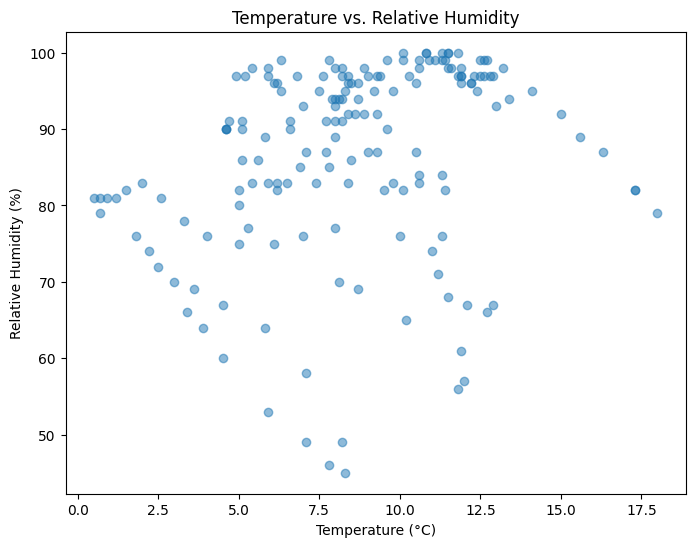

In [14]:
# Scatter Plot of Temperature vs. Relative Humidity

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature_2m'], df['relativehumidity_2m'], alpha=0.5)
plt.title('Temperature vs. Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


In [15]:
# Step 7: Resample Data to Daily Averages

daily_avg = df.resample('D').mean()
daily_avg.head()


,temperature_2m,relativehumidity_2m,precipitation
time,,,
2023-01-01,9.008333,83.708333,0.087500
2023-01-02,7.916667,83.458333,0.020833
2023-01-03,9.575000,96.875000,0.395833
2023-01-04,13.154167,94.166667,0.095833
2023-01-05,10.070833,92.666667,0.000000


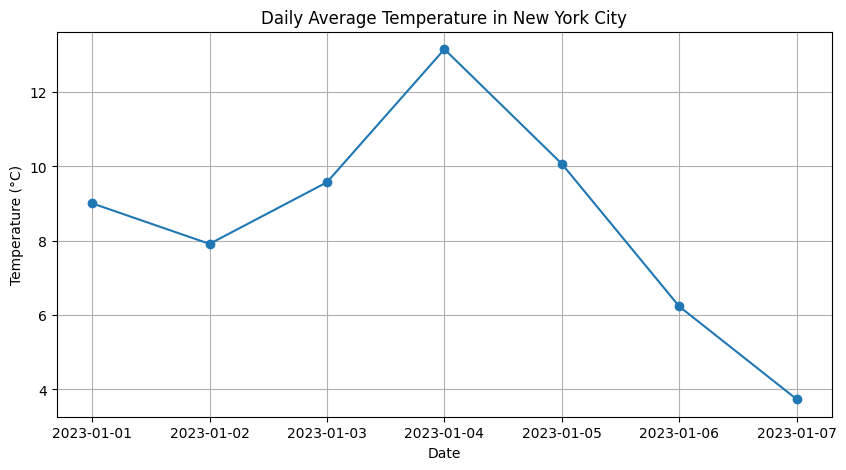

In [16]:
# Plot Daily Average Temperature

plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg['temperature_2m'], marker='o')
plt.title('Daily Average Temperature in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


In [17]:
# Step 8: Compare with Another Location (Los Angeles)

# Coordinates for Los Angeles
latitude_la = 34.0522
longitude_la = -118.2437

params_la = {
    'latitude': latitude_la,
    'longitude': longitude_la,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_la = requests.get(base_url, params=params_la)

# Load and clean Los Angeles data
data_la = response_la.json()
hourly_data_la = data_la['hourly']
df_la = pd.DataFrame(hourly_data_la)

df_la['time'] = pd.to_datetime(df_la['time'])
df_la.set_index('time', inplace=True)
df.ffill(inplace=True)

In [18]:
# Resample Los Angeles Data to Daily Averages

daily_avg_la = df_la.resample('D').mean()


In [19]:
# Combine DataFrames for Comparison

combined_temp = pd.DataFrame({
    'New York': daily_avg['temperature_2m'],
    'Los Angeles': daily_avg_la['temperature_2m']
})


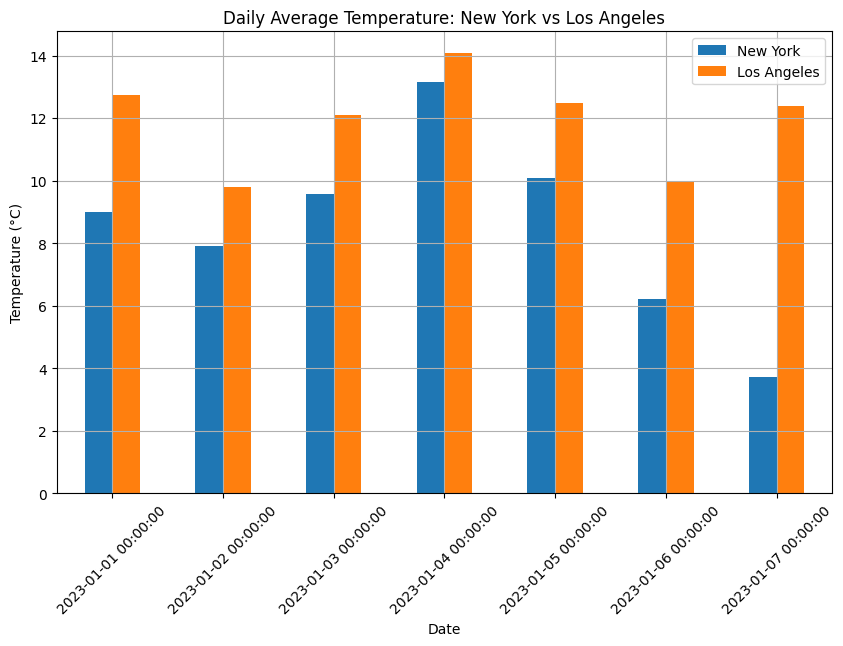

In [20]:
# Plot Comparison of Daily Average Temperature

combined_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Daily Average Temperature: New York vs Los Angeles')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [21]:
# Step 9: Advanced Analysis - Temperature Difference

# Calculate Temperature Difference
combined_temp['Temp Difference'] = combined_temp['Los Angeles'] - combined_temp['New York']
combined_temp


,New York,Los Angeles,Temp Difference
time,,,
2023-01-01,9.008333,12.733333,3.725000
2023-01-02,7.916667,9.783333,1.866667
2023-01-03,9.575000,12.108333,2.533333
2023-01-04,13.154167,14.066667,0.912500
2023-01-05,10.070833,12.483333,2.412500
2023-01-06,6.233333,9.962500,3.729167
2023-01-07,3.737500,12.395833,8.658333


In [22]:
# Step 10: Save Data to CSV (Optional)

# Save New York data
df.to_csv('new_york_weather.csv')

# Save Los Angeles data
df_la.to_csv('los_angeles_weather.csv')


## Conclusion

In this exercise, we:

- Accessed and retrieved data from the **Open-Meteo API**.
- Cleaned and preprocessed JSON data using **pandas**.
- Performed exploratory data analysis and visualization.
- Compared weather patterns between **New York City** and **Los Angeles**.

---

**Next Steps**:

- **Extend the Date Range**: Analyze seasonal trends by fetching data over several months.
- **Fetch Additional Variables**: Include wind speed, atmospheric pressure, or other interesting variables.
- **Forecasting**: Use statistical methods or machine learning models to forecast future weather patterns.
- **Global Analysis**: Compare data from other global cities to gain broader insights.


## Exercises for Students

Now it's your turn! Below are some exercises to reinforce what you've learned. Try to complete them without looking at the solutions.

### Exercise: Compare Rainfall Between London and Seattle

- **Objective**: Compare the total weekly rainfall between London and Seattle over a full year.
- **Tasks**:
  1. **Fetch Data**: Retrieve hourly precipitation data for London and Seattle for the year 2022.
     - **London Coordinates**: Latitude `51.5074`, Longitude `-0.1278`
     - **Seattle Coordinates**: Latitude `47.6062`, Longitude `-122.3321`
  2. **Data Cleaning**: Convert the time columns to datetime objects and set them as the index. Handle any missing values.
  3. **Resample Data**: Resample the hourly data to weekly totals.
  4. **Visualization**: Plot the weekly total precipitation for both cities on the same graph.
  5. **Analysis**: Determine which city had more rainfall overall and identify any interesting patterns.

**Note**: Remember to handle any API limitations, such as data availability or rate limits, and to be mindful of the size of the data you're requesting.

### Tips:

- **API Parameters**: Make sure to adjust the parameters like `latitude`, `longitude`, `start_date`, `end_date`, `hourly`, and `timezone` as needed.
- **Error Handling**: Always check if your API requests are successful before proceeding.
- **Data Storage**: Consider saving your DataFrames to CSV files for future analysis.
- **Visualization**: Customize your plots with titles, labels, legends, and gridlines for better readability.

Happy coding!


## Exercise 3.1: Compare Rainfall Between London and Seattle

### Step 1: Import libraries and set up API parameters

In [23]:
# Import the libraries needed for this exercise
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Open-Meteo historical weather API endpoint
base_url = 'https://archive-api.open-meteo.com/v1/archive'

# Set the date range for the analysis
# We are analyzing the entire year of 2022
start_date = '2022-01-01'
end_date = '2022-12-31'

# We only need hourly precipitation data for this exercise
hourly_variable = 'precipitation'

### Step 2: Fetch London precipitation data

In [24]:
# Coordinates for London, United Kingdom
latitude_london = 51.5074
longitude_london = -0.1278

# Create the parameters for the London API request
params_london = {
    'latitude': latitude_london,
    'longitude': longitude_london,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': hourly_variable,
    'timezone': 'Europe/London'
}

# Send the API request for London's hourly precipitation data
response_london = requests.get(base_url, params=params_london)

# Check whether the API request was successful
if response_london.status_code == 200:
    print('London data fetched successfully!')
else:
    print(f'Failed to fetch London data. Status code: {response_london.status_code}')

London data fetched successfully!


### Step 3: Load and clean London's data

In [25]:
# Convert the API response from JSON format into a Python dictionary
data_london = response_london.json()

# Extract the hourly weather data from the JSON response
hourly_data_london = data_london['hourly']

# Convert the hourly data into a pandas DataFrame
df_london = pd.DataFrame(hourly_data_london)

# Convert the 'time' column from text to pandas datetime format
df_london['time'] = pd.to_datetime(df_london['time'])

# Set the 'time' column as the DataFrame index
df_london.set_index('time', inplace=True)

# Check for missing precipitation values
print('Missing values in London data:')
print(df_london.isnull().sum())

# Forward-fill any missing values
# This uses the previous available observation to fill a missing value
df_london.ffill(inplace=True)

# Display the first five rows to verify the data
df_london.head()

Missing values in London data:
precipitation    0
dtype: int64


,precipitation
time,
2022-01-01 00:00:00,0.0
2022-01-01 01:00:00,0.0
2022-01-01 02:00:00,0.0
2022-01-01 03:00:00,0.0
2022-01-01 04:00:00,0.0


### Step 4: Fetch Seattle precipitation data

In [26]:
# Coordinates for Seattle, Washington
latitude_seattle = 47.6062
longitude_seattle = -122.3321

# Create the parameters for the Seattle API request
params_seattle = {
    'latitude': latitude_seattle,
    'longitude': longitude_seattle,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': hourly_variable,
    'timezone': 'America/Los_Angeles'
}

# Send the API request for Seattle's hourly precipitation data
response_seattle = requests.get(base_url, params=params_seattle)

# Check whether the API request was successful
if response_seattle.status_code == 200:
    print('Seattle data fetched successfully!')
else:
    print(f'Failed to fetch Seattle data. Status code: {response_seattle.status_code}')

Seattle data fetched successfully!


### Step 5: Load and clean Seattle's data

In [27]:
# Convert the API response from JSON into a Python dictionary
data_seattle = response_seattle.json()

# Extract the hourly weather data from the JSON response
hourly_data_seattle = data_seattle['hourly']

# Convert the hourly data into a pandas DataFrame
df_seattle = pd.DataFrame(hourly_data_seattle)

# Convert the 'time' column to pandas datetime format
df_seattle['time'] = pd.to_datetime(df_seattle['time'])

# Set the 'time' column as the DataFrame index
df_seattle.set_index('time', inplace=True)

# Check for missing precipitation values
print('Missing values in Seattle data:')
print(df_seattle.isnull().sum())

# Forward-fill any missing values
df_seattle.ffill(inplace=True)

# Display the first five rows
df_seattle.head()

Missing values in Seattle data:
precipitation    0
dtype: int64


,precipitation
time,
2022-01-01 00:00:00,0.0
2022-01-01 01:00:00,0.0
2022-01-01 02:00:00,0.0
2022-01-01 03:00:00,0.0
2022-01-01 04:00:00,0.0


### Step 6: Resample hourly data to weekly totals

In [28]:
# Resample London's hourly precipitation data into weekly totals
# 'W' means weekly frequency and sum() calculates the total precipitation
weekly_london = df_london['precipitation'].resample('W').sum()

# Resample Seattle's hourly precipitation data into weekly totals
weekly_seattle = df_seattle['precipitation'].resample('W').sum()

# Display the first five weekly totals for each city
print('London weekly rainfall:')
print(weekly_london.head())

print('\nSeattle weekly rainfall:')
print(weekly_seattle.head())

London weekly rainfall:
time
2022-01-02     2.2
2022-01-09    12.9
2022-01-16     3.1
2022-01-23     0.0
2022-01-30     0.1
Freq: W-SUN, Name: precipitation, dtype: float64

Seattle weekly rainfall:
time
2022-01-02     31.3
2022-01-09    108.8
2022-01-16     45.5
2022-01-23     15.7
2022-01-30      6.1
Freq: W-SUN, Name: precipitation, dtype: float64


### Step 7: Combine London and Seattle data

In [29]:
# Combine the weekly rainfall data from both cities into one DataFrame
weekly_rainfall = pd.DataFrame({
    'London': weekly_london,
    'Seattle': weekly_seattle
})

# Display the first five weeks for comparison
weekly_rainfall.head()

,London,Seattle
time,,
2022-01-02,2.2,31.3
2022-01-09,12.9,108.8
2022-01-16,3.1,45.5
2022-01-23,0.0,15.7
2022-01-30,0.1,6.1


### Step 8: Plot weekly rainfall

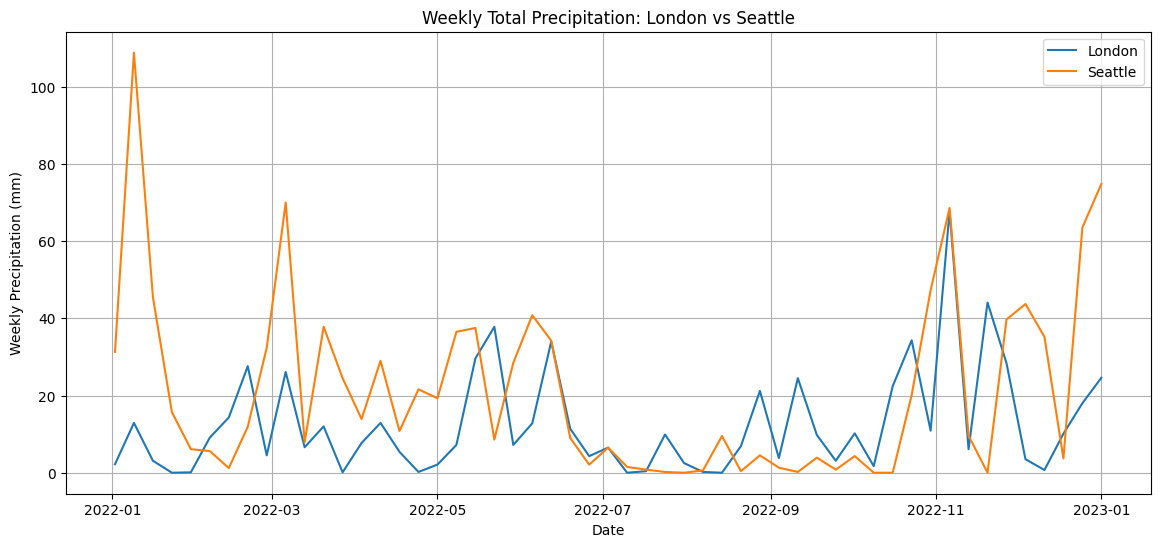

In [30]:
# Create a figure for the comparison plot
plt.figure(figsize=(14, 6))

# Plot London's weekly rainfall
plt.plot(
    weekly_rainfall.index,
    weekly_rainfall['London'],
    label='London'
)

# Plot Seattle's weekly rainfall
plt.plot(
    weekly_rainfall.index,
    weekly_rainfall['Seattle'],
    label='Seattle'
)

# Add a title and axis labels
plt.title('Weekly Total Precipitation: London vs Seattle')
plt.xlabel('Date')
plt.ylabel('Weekly Precipitation (mm)')

# Display the legend so we can distinguish the two cities
plt.legend()

# Add gridlines to make the chart easier to read
plt.grid(True)

# Display the plot
plt.show()

### Step 9: Calculate total rainfall for the entire year

In [31]:
# Add all weekly rainfall totals to calculate the total rainfall for the year
total_london = weekly_london.sum()
total_seattle = weekly_seattle.sum()

# Display the total annual precipitation for each city
print(f'Total rainfall in London during 2022: {total_london:.2f} mm')
print(f'Total rainfall in Seattle during 2022: {total_seattle:.2f} mm')

Total rainfall in London during 2022: 662.80 mm
Total rainfall in Seattle during 2022: 1131.20 mm


### Step 10: Determine which city had more rainfall

In [32]:
# Compare the total annual rainfall between the two cities
if total_london > total_seattle:
    print('London had more rainfall overall in 2022.')
elif total_seattle > total_london:
    print('Seattle had more rainfall overall in 2022.')
else:
    print('London and Seattle had the same amount of rainfall.')

Seattle had more rainfall overall in 2022.


### Step 11: Find the wettest we  ek for each city

In [33]:
# Find London's week with the highest total precipitation
wettest_week_london = weekly_london.idxmax()
max_rain_london = weekly_london.max()

# Find Seattle's week with the highest total precipitation
wettest_week_seattle = weekly_seattle.idxmax()
max_rain_seattle = weekly_seattle.max()

# Display the wettest week and rainfall amount for each city
print(f'London wettest week: {wettest_week_london.date()} '
      f'with {max_rain_london:.2f} mm of rainfall')

print(f'Seattle wettest week: {wettest_week_seattle.date()} '
      f'with {max_rain_seattle:.2f} mm of rainfall')

London wettest week: 2022-11-06 with 67.80 mm of rainfall
Seattle wettest week: 2022-01-09 with 108.80 mm of rainfall


### Step 13: My analysis

### Analysis: <br> <br> In 2022, London received approximately **662.80 mm** of total precipitation, while Seattle received approximately **1131.20 mm**. Therefore, Seattle had more rainfall overall. The weekly precipitation graph shows that rainfall varied throughout the year, with some weeks experiencing substantially higher precipitation than others. The wettest week in London occurred on 2022-11-06, while Seattle's wettest week occurred on 2022-01-09. These patterns show that precipitation was not evenly distributed throughout the year.